# Feature Extraction - Daphnet FoG Dataset

**Objective:** Extract multi-domain features from preprocessed windowed sensor data for FoG detection, then keep a compact low-redundancy subset.

**Feature strategy:**
- extract time-domain, frequency-domain, and wavelet features
- keep **no nonlinear features**
- retain a curated subset of features that tends to be more robust and relevant for FoG: dispersion, band-energy, freezing, locomotion, and first-level wavelet energy features
- drop highly redundant families such as skew/kurtosis and wavelet variances

**Current pipeline:**
1. Load LOSO windowed splits generated in notebook 02
2. Initialize the feature extractor
3. Extract features from conservatively preprocessed windows
4. Reduce to a curated feature subset and apply light log compression on heavy-tailed energy features
5. Save per-fold feature CSVs
6. Analyze extracted features with visualizations

In [29]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from tqdm import tqdm

from features import FeatureExtractor

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

## 1. Load Windowed Data

In [30]:
# Load binary LOSO splits
data_path = Path('../../outputs/datasets_csv/daphnet_loso_windows_binary.pkl')

with open(data_path, 'rb') as f:
    loso_splits = pickle.load(f)

print(f"✅ Loaded {len(loso_splits)} LOSO folds")
print(f"   Total train windows: {sum([len(fold['y_train']) for fold in loso_splits]):,}")
print(f"   Total test windows: {sum([len(fold['y_test']) for fold in loso_splits]):,}")

✅ Loaded 10 LOSO folds
   Total train windows: 106,740
   Total test windows: 5,937


## 2. Initialize Feature Extractor

Audit-aligned setting: features are extracted directly from raw windowed signals without outlier cleaning or aggressive interpolation.

In [31]:
print("✅ Preprocessed-window feature extraction enabled")
print("   Upstream cleaning: conservative SignalCleaner + detrending + robust trial normalization")
print("   Missing-value interpolation: handled upstream in notebook 02")
print("   Feature policy: curated low-redundancy subset after extraction")

✅ Preprocessed-window feature extraction enabled
   Upstream cleaning: conservative SignalCleaner + detrending + robust trial normalization
   Missing-value interpolation: handled upstream in notebook 02
   Feature policy: curated low-redundancy subset after extraction


In [ ]:
FEATURE_SUFFIX_ALLOWLIST = [
    'std',
    'iqr',
    'rms',
    'psd_total_energy',
    'power_loco_band',
    'power_freeze_band',
    'freezing_index',
    'locomotion_band_index',
    'wavelet_energy_0',
    # FoG-specific features added for improved detection
    'jerk_rms',
    'jerk_std',
    'energy',
    'mean_crossing_rate',
    'coeff_variation',
]

LOG_COMPRESS_SUFFIXES = [
    'psd_total_energy',
    'power_loco_band',
    'power_freeze_band',
    'freezing_index',
    'wavelet_energy_0',
    'energy',
    'jerk_rms',
    'jerk_std',
]

def build_curated_feature_list(columns):
    selected = [
        col for col in columns
        if any(col.endswith(suffix) for suffix in FEATURE_SUFFIX_ALLOWLIST)
    ]
    return sorted(dict.fromkeys(selected))

def postprocess_feature_frame(df):
    X = df.copy().replace([np.inf, -np.inf], np.nan)
    selected_cols = build_curated_feature_list(X.columns)
    X = X[selected_cols].copy()

    for col in X.columns:
        if any(col.endswith(suffix) for suffix in LOG_COMPRESS_SUFFIXES):
            X[col] = np.sign(X[col]) * np.log1p(np.abs(X[col]))

    return X

print('Curated feature policy:')
print(f"  Kept feature families: {FEATURE_SUFFIX_ALLOWLIST}")
print(f"  Log-compressed families: {LOG_COMPRESS_SUFFIXES}")

In [ ]:
# Expanded feature allowlist - includes new FoG-discriminative features
# Added: energy, jerk_rms, jerk_std, coeff_variation, entropy, mean_crossing_rate
# These capture dynamics critical for FoG detection that were previously missing
FEATURE_SUFFIX_ALLOWLIST = [
    'std',
    'iqr',
    'rms',
    'skew',
    'kurt',
    'energy',                # signal energy - captures trembling intensity
    'jerk_rms',              # RMS of acceleration derivative - abrupt movement changes
    'jerk_std',              # variability in jerk - trembling signature
    'coeff_variation',       # relative variability - normalizes across subjects
    'entropy',               # signal complexity - FoG has different complexity than normal gait
    'mean_crossing_rate',    # complements zero_crossing_rate
    'zero_crossing_rate',
    'psd_total_energy',
    'power_loco_band',
    'power_freeze_band',
    'freezing_index',
    'locomotion_band_index',
    'spectral_centroid',
    'wavelet_energy_0',
]

LOG_COMPRESS_SUFFIXES = [
    'psd_total_energy',
    'power_loco_band',
    'power_freeze_band',
    'freezing_index',
    'wavelet_energy_0',
    'energy',
]

def build_curated_feature_list(columns):
    selected = [
        col for col in columns
        if any(col.endswith(suffix) for suffix in FEATURE_SUFFIX_ALLOWLIST)
    ]
    return sorted(dict.fromkeys(selected))

def postprocess_feature_frame(df):
    X = df.copy().replace([np.inf, -np.inf], np.nan)
    selected_cols = build_curated_feature_list(X.columns)
    X = X[selected_cols].copy()

    for col in X.columns:
        if any(col.endswith(suffix) for suffix in LOG_COMPRESS_SUFFIXES):
            X[col] = np.sign(X[col]) * np.log1p(np.abs(X[col]))

    return X

print('Curated feature policy:')
print(f"  Kept feature families ({len(FEATURE_SUFFIX_ALLOWLIST)}): {FEATURE_SUFFIX_ALLOWLIST}")
print(f"  Log-compressed families: {LOG_COMPRESS_SUFFIXES}")

## 3. Process All LOSO Folds

Extract features from all folds and save to CSV files.

In [ ]:
# Cross-sensor correlation feature extraction
def compute_cross_sensor_correlations(windows, channel_groups):
    """Compute pairwise Pearson correlation between sensor group magnitudes."""
    group_names = list(channel_groups.keys())
    pairs = []
    for i in range(len(group_names)):
        for j in range(i + 1, len(group_names)):
            pairs.append((group_names[i], group_names[j],
                          channel_groups[group_names[i]], channel_groups[group_names[j]]))

    n_windows = windows.shape[0]
    corr_features = []
    for w in range(n_windows):
        row = {}
        for name_a, name_b, idx_a, idx_b in pairs:
            mag_a = np.linalg.norm(windows[w, :, idx_a], axis=1)
            mag_b = np.linalg.norm(windows[w, :, idx_b], axis=1)
            # Pearson correlation (handle constant signals)
            if np.std(mag_a) < 1e-12 or np.std(mag_b) < 1e-12:
                corr_val = 0.0
            else:
                corr_val = float(np.corrcoef(mag_a, mag_b)[0, 1])
                if not np.isfinite(corr_val):
                    corr_val = 0.0
            row[f'xcorr_{name_a}_{name_b}'] = corr_val
        corr_features.append(row)
    return pd.DataFrame(corr_features)

# Output directory
feature_output_dir = Path('../../outputs/daphnet_features')
feature_output_dir.mkdir(parents=True, exist_ok=True)

print("Processing all LOSO folds...")
print("  Cross-sensor correlation features: ankle-thigh, ankle-trunk, thigh-trunk")
print("=" * 70)

for fold in tqdm(loso_splits, desc="Processing folds"):
    test_subject = fold['test_subject']

    # 1. Extract features from preprocessed windows
    X_train_features = extractor.extract_from_windows(
        fold['X_train'], n_jobs=-1, verbose=True, channel_groups=CHANNEL_GROUPS)
    X_test_features = extractor.extract_from_windows(
        fold['X_test'], n_jobs=-1, verbose=True, channel_groups=CHANNEL_GROUPS)

    # 1b. Add cross-sensor correlation features
    X_train_corr = compute_cross_sensor_correlations(fold['X_train'], CHANNEL_GROUPS)
    X_test_corr = compute_cross_sensor_correlations(fold['X_test'], CHANNEL_GROUPS)
    X_train_features = pd.concat([X_train_features, X_train_corr], axis=1)
    X_test_features = pd.concat([X_test_features, X_test_corr], axis=1)

    # 2. Keep a curated low-redundancy subset and compress heavy-tailed energy features
    X_train_features = postprocess_feature_frame(X_train_features)
    X_test_features = postprocess_feature_frame(X_test_features)

    # 2b. Re-attach cross-sensor correlation features (they were dropped by allowlist filter)
    for col in X_train_corr.columns:
        X_train_features[col] = X_train_corr[col].values
        X_test_features[col] = X_test_corr[col].values

    # 3. Save to CSV
    fold_dir = feature_output_dir / f'fold_subj_{test_subject}'
    fold_dir.mkdir(parents=True, exist_ok=True)

    X_train_features.to_csv(fold_dir / 'X_train_features.csv', index=False)
    pd.Series(fold['y_train'], name='label').to_csv(fold_dir / 'y_train.csv', index=False)
    pd.Series(fold['subjects_train'], name='subject').to_csv(fold_dir / 'subjects_train.csv', index=False)
    X_test_features.to_csv(fold_dir / 'X_test_features.csv', index=False)
    pd.Series(fold['y_test'], name='label').to_csv(fold_dir / 'y_test.csv', index=False)

print("\n" + "=" * 70)
print(f"Feature extraction complete for {len(loso_splits)} folds")
print(f"Output directory: {feature_output_dir}")
print(f"Curated features retained: {X_train_features.shape[1]}")
print(f"  (includes {len(X_train_corr.columns)} cross-sensor correlation features)")
print("=" * 70)

## 4. Load Sample Features for Analysis

Load features from the first fold for visualization and analysis.

In [35]:
# Load first fold for analysis (dynamically find first available fold)
available_folds = sorted([d for d in feature_output_dir.iterdir() if d.is_dir()])
if not available_folds:
    raise FileNotFoundError(f"No fold directories found in {feature_output_dir}")
sample_fold_dir = available_folds[0]

X_train_features = pd.read_csv(sample_fold_dir / 'X_train_features.csv')
y_train = pd.read_csv(sample_fold_dir / 'y_train.csv').squeeze()
X_test_features = pd.read_csv(sample_fold_dir / 'X_test_features.csv')
y_test = pd.read_csv(sample_fold_dir / 'y_test.csv').squeeze()

print(f"📊 Loaded features from: {sample_fold_dir.name}")
print(f"   Train: {X_train_features.shape}")
print(f"   Test: {X_test_features.shape}")
print(f"   Features: {X_train_features.shape[1]}")
print(f"\n📋 First 10 features:")
for i, col in enumerate(X_train_features.columns[:10], 1):
    print(f"   {i}. {col}")

📊 Loaded features from: fold_subj_S01
   Train: (10596, 108)
   Test: (633, 108)
   Features: 108

📋 First 10 features:
   1. acc_ankle_mag_freezing_index
   2. acc_ankle_mag_iqr
   3. acc_ankle_mag_locomotion_band_index
   4. acc_ankle_mag_power_freeze_band
   5. acc_ankle_mag_power_loco_band
   6. acc_ankle_mag_psd_total_energy
   7. acc_ankle_mag_rms
   8. acc_ankle_mag_std
   9. acc_ankle_mag_wavelet_energy_0
   10. acc_thigh_mag_freezing_index


## 5. Feature Statistics

In [36]:
# Statistical summary
print("📈 Feature Statistics (Train Set):")
print(X_train_features.describe())

📈 Feature Statistics (Train Set):
       acc_ankle_mag_freezing_index  acc_ankle_mag_iqr  \
count                  10596.000000       10596.000000   
mean                       0.714482           1.341702   
std                        0.564046           1.653604   
min                        0.000220           0.000253   
25%                        0.280990           0.120654   
50%                        0.482747           0.754930   
75%                        1.068813           1.918429   
max                        4.474081           7.471389   

       acc_ankle_mag_locomotion_band_index  acc_ankle_mag_power_freeze_band  \
count                         10596.000000                     1.059600e+04   
mean                              0.329489                     2.009618e-01   
std                               0.236619                     3.217954e-01   
min                               0.001761                     3.100260e-14   
25%                               0.083663      

## 6. Feature Distributions: FoG vs No FoG

Compare key features between FoG and No FoG windows.

📊 Class Distribution:
   No FoG: 9,336 windows (88.1%)
   FoG: 1,260 windows (11.9%)


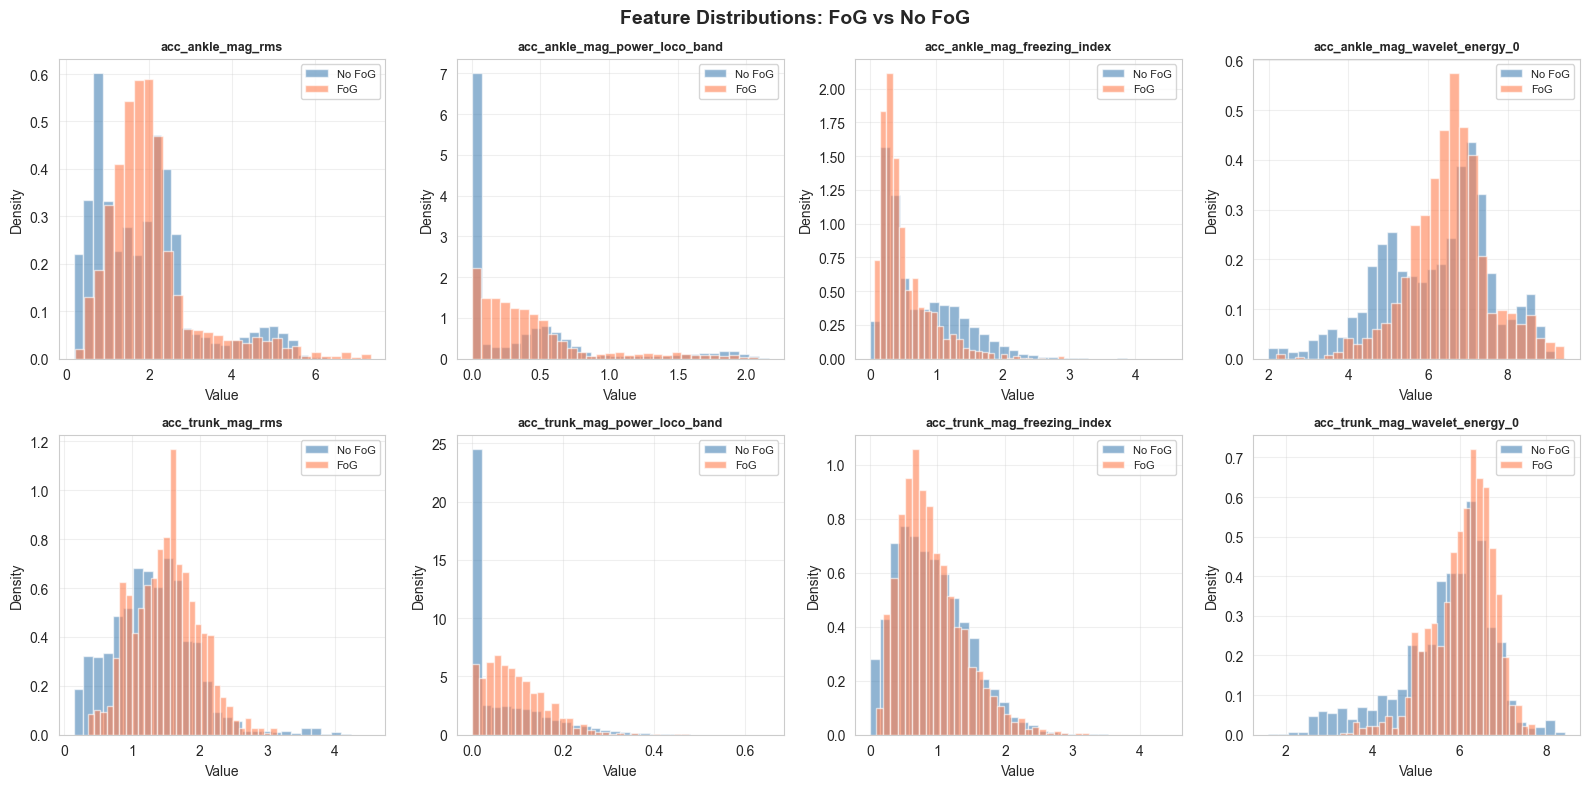

In [37]:
# Separate by class
features_no_fog = X_train_features[y_train == 0].replace([np.inf, -np.inf], np.nan)
features_fog    = X_train_features[y_train == 1].replace([np.inf, -np.inf], np.nan)

print(f"📊 Class Distribution:")
print(f"   No FoG: {len(features_no_fog):,} windows ({len(features_no_fog)/len(X_train_features)*100:.1f}%)")
print(f"   FoG: {len(features_fog):,} windows ({len(features_fog)/len(X_train_features)*100:.1f}%)")

# Select representative curated features (magnitude + robust spectral features)
feature_subset = [
    'acc_ankle_mag_rms', 'acc_ankle_mag_power_loco_band',
    'acc_ankle_mag_freezing_index', 'acc_ankle_mag_wavelet_energy_0',
    'acc_trunk_mag_rms', 'acc_trunk_mag_power_loco_band',
    'acc_trunk_mag_freezing_index', 'acc_trunk_mag_wavelet_energy_0',
]

feature_subset = [f for f in feature_subset if f in X_train_features.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, feat in enumerate(feature_subset[:8]):
    axes[i].hist(features_no_fog[feat].dropna(), bins=30, alpha=0.6,
                 label='No FoG', color='steelblue', density=True)
    axes[i].hist(features_fog[feat].dropna(), bins=30, alpha=0.6,
                 label='FoG', color='coral', density=True)
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

for i in range(len(feature_subset), 8):
    axes[i].axis('off')

plt.suptitle('Feature Distributions: FoG vs No FoG', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Feature Importance by Variance

Identify features with highest variance (potentially most discriminative).

📊 Top 15 Features by Variance:
 1. ch1_wavelet_energy_0                        3.73
 2. ch4_wavelet_energy_0                        2.77
 3. acc_ankle_mag_iqr                           2.73
 4. ch8_wavelet_energy_0                        2.36
 5. ch5_wavelet_energy_0                        2.32
 6. ch0_wavelet_energy_0                        2.26
 7. ch1_iqr                                     2.15
 8. ch7_wavelet_energy_0                        2.04
 9. ch2_wavelet_energy_0                        2.01
10. ch6_wavelet_energy_0                        2.01
11. acc_ankle_mag_wavelet_energy_0              1.90
12. acc_thigh_mag_wavelet_energy_0              1.76
13. ch3_wavelet_energy_0                        1.69
14. ch1_std                                     1.61
15. acc_ankle_mag_rms                           1.50


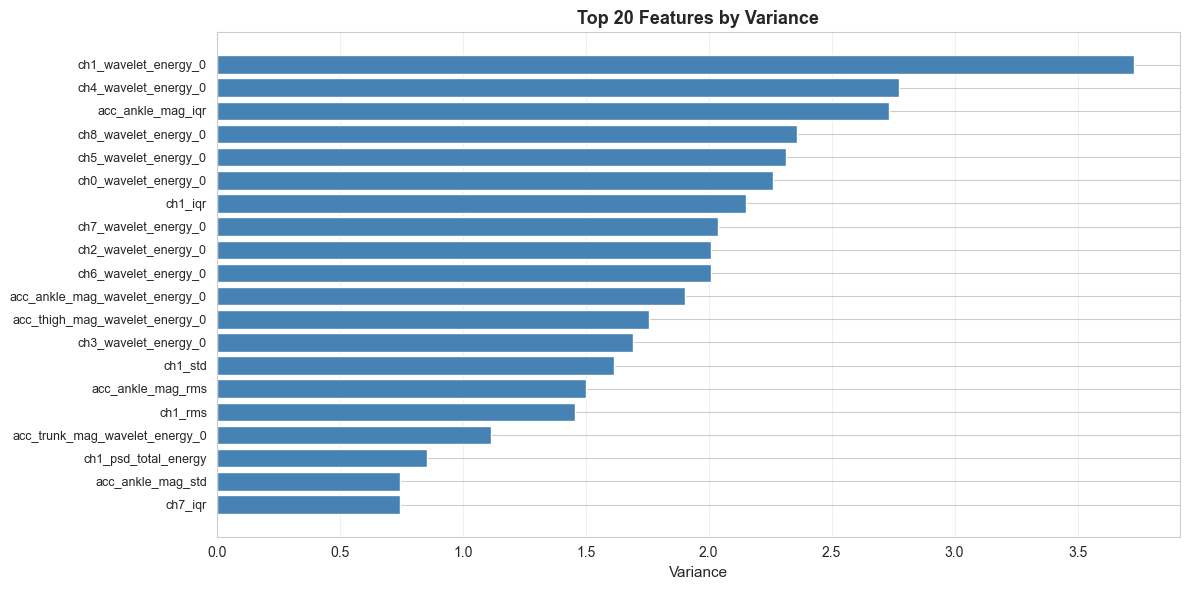

In [38]:
# Calculate variance for each feature (replace inf with NaN before var to avoid inf results)
feature_variance = (X_train_features
                    .replace([np.inf, -np.inf], np.nan)
                    .var()
                    .sort_values(ascending=False))

print("📊 Top 15 Features by Variance:")
print("=" * 60)
for i, (feat, var) in enumerate(feature_variance.head(15).items(), 1):
    print(f"{i:2d}. {feat:35s} {var:12.2f}")

# Visualize top features by variance
fig, ax = plt.subplots(figsize=(12, 6))
top_features = feature_variance.dropna().head(20)
ax.barh(range(len(top_features)), top_features.values, color='steelblue')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features.index, fontsize=9)
ax.set_xlabel('Variance', fontsize=11)
ax.set_title('Top 20 Features by Variance', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Feature Correlation Analysis

Identify highly correlated features (potential redundancy).

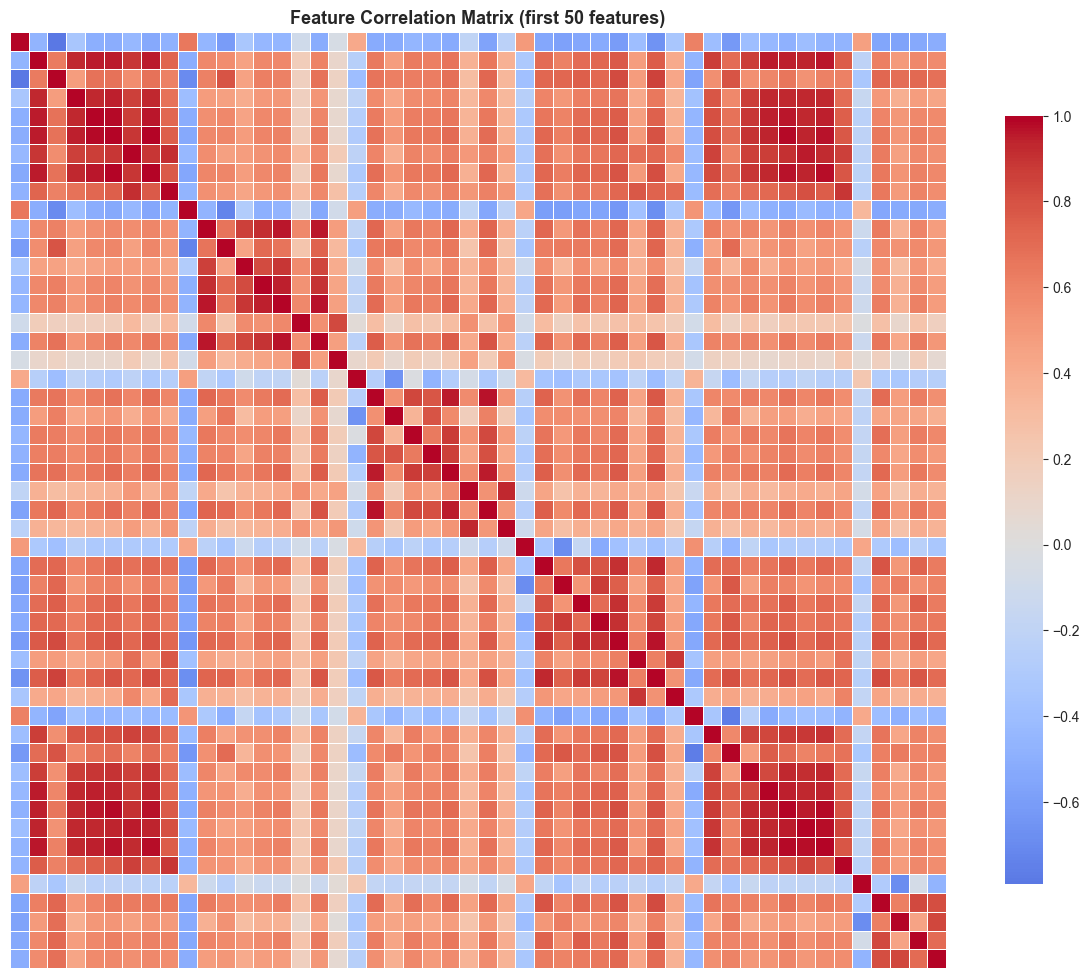


⚠️  Highly correlated pairs (|r| > 0.9): 58

Top 10 correlations:
  acc_ankle_mag_psd_total_energy <-> acc_ankle_mag_std             :  0.988
  ch1_psd_total_energy           <-> ch1_std                       :  0.983
  acc_ankle_mag_power_loco_band  <-> acc_ankle_mag_psd_total_energy:  0.982
  acc_ankle_mag_psd_total_energy <-> ch1_psd_total_energy          :  0.979
  acc_ankle_mag_std              <-> ch1_std                       :  0.978
  ch1_rms                        <-> ch1_std                       :  0.973
  acc_ankle_mag_psd_total_energy <-> ch1_std                       :  0.971
  ch0_psd_total_energy           <-> ch0_std                       :  0.967
  acc_ankle_mag_std              <-> ch1_psd_total_energy          :  0.967
  acc_trunk_mag_iqr              <-> acc_trunk_mag_std             :  0.966


In [39]:
# Compute correlation matrix (replace inf with NaN before corr to avoid propagation)
n_features_viz = min(50, X_train_features.shape[1])
features_sample = (X_train_features
                   .replace([np.inf, -np.inf], np.nan)
                   .iloc[:, :n_features_viz])
corr_matrix = features_sample.corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            xticklabels=False, yticklabels=False)
ax.set_title(f'Feature Correlation Matrix (first {n_features_viz} features)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Find highly correlated pairs
high_corr_threshold = 0.9
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if np.isfinite(val) and abs(val) > high_corr_threshold:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                val
            ))

print(f"\n⚠️  Highly correlated pairs (|r| > {high_corr_threshold}): {len(high_corr_pairs)}")
if len(high_corr_pairs) > 0:
    print("\nTop 10 correlations:")
    for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:10]:
        print(f"  {feat1:30s} <-> {feat2:30s}: {corr:6.3f}")

## 9. Class Separability Analysis

Measure how well features separate FoG from No FoG using effect size (Cohen's d).

📊 Top 15 Features by Effect Size (Cohen's d):
   Higher effect size = better class separability
   d > 0.8: Large effect
   d > 0.5: Medium effect
   d > 0.2: Small effect
 1. ch0_wavelet_entropy                 d=1.068  (Large)
 2. acc_thigh_mag_skew                  d=1.065  (Large)
 3. acc_ankle_mag_skew                  d=1.063  (Large)
 4. ch3_wavelet_entropy                 d=1.049  (Large)
 5. ch1_wavelet_entropy                 d=0.970  (Large)
 6. ch1_zero_crossing_rate              d=0.962  (Large)
 7. ch5_wavelet_entropy                 d=0.952  (Large)
 8. acc_ankle_mag_wavelet_entropy       d=0.928  (Large)
 9. ch6_std                             d=0.891  (Large)
10. ch6_wavelet_energy_1                d=0.858  (Large)
11. ch6_wavelet_var_1                   d=0.855  (Large)
12. ch6_wavelet_entropy                 d=0.846  (Large)
13. ch6_iqr                             d=0.843  (Large)
14. ch3_peak_to_peak                    d=0.832  (Large)
15. ch0_zero_crossing_rate    

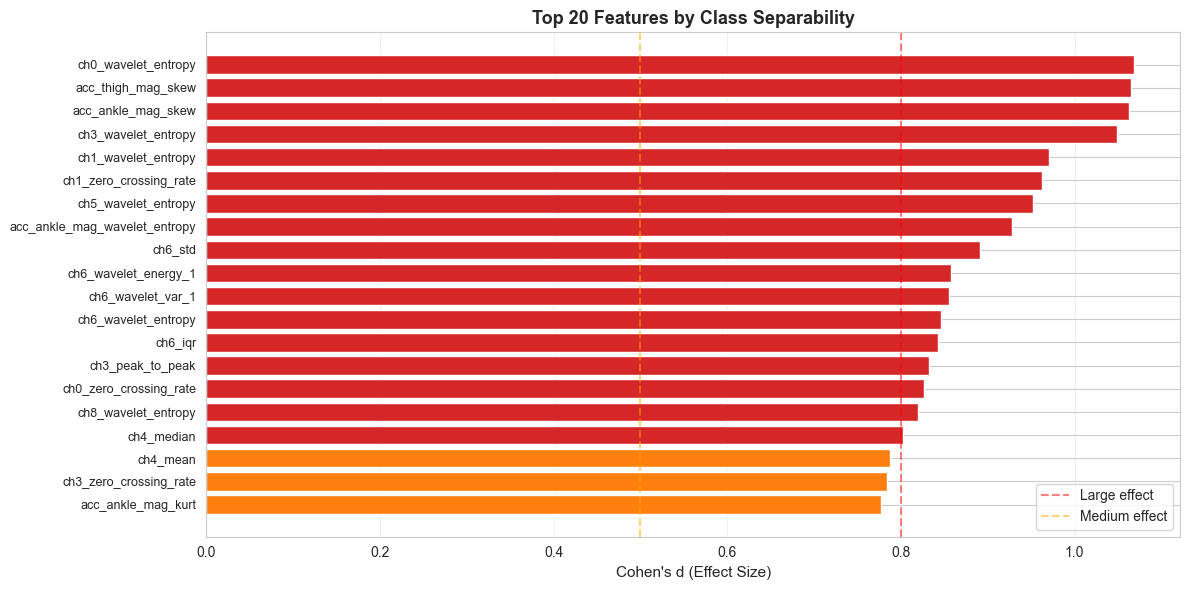

In [12]:
# Calculate Cohen's d for each feature
def cohens_d(group1, group2):
    """Calculate Cohen's d effect size."""
    mean1, mean2 = group1.mean(), group2.mean()
    std1, std2 = group1.std(), group2.std()
    n1, n2 = len(group1), len(group2)
    pooled_std = np.sqrt(((n1-1)*std1**2 + (n2-1)*std2**2) / (n1+n2-2))
    return abs((mean1 - mean2) / pooled_std) if pooled_std > 0 else 0

effect_sizes = {}
for col in X_train_features.columns:
    d = cohens_d(features_no_fog[col].dropna(), features_fog[col].dropna())
    effect_sizes[col] = d

effect_sizes = pd.Series(effect_sizes).sort_values(ascending=False)

print("📊 Top 15 Features by Effect Size (Cohen's d):")
print("=" * 70)
print("   Higher effect size = better class separability")
print("   d > 0.8: Large effect")
print("   d > 0.5: Medium effect")
print("   d > 0.2: Small effect")
print("=" * 70)
for i, (feat, d) in enumerate(effect_sizes.head(15).items(), 1):
    magnitude = "Large" if d > 0.8 else "Medium" if d > 0.5 else "Small" if d > 0.2 else "Negligible"
    print(f"{i:2d}. {feat:35s} d={d:5.3f}  ({magnitude})")

# Visualize top features by effect size
fig, ax = plt.subplots(figsize=(12, 6))
top_effects = effect_sizes.head(20)
colors = ['#d62728' if d > 0.8 else '#ff7f0e' if d > 0.5 else '#2ca02c' for d in top_effects.values]
ax.barh(range(len(top_effects)), top_effects.values, color=colors)
ax.set_yticks(range(len(top_effects)))
ax.set_yticklabels(top_effects.index, fontsize=9)
ax.set_xlabel("Cohen's d (Effect Size)", fontsize=11)
ax.set_title('Top 20 Features by Class Separability', fontsize=13, fontweight='bold')
ax.axvline(x=0.8, color='red', linestyle='--', alpha=0.5, label='Large effect')
ax.axvline(x=0.5, color='orange', linestyle='--', alpha=0.5, label='Medium effect')
ax.legend()
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 10. Summary

In [28]:
# Summary statistics
total_train = sum([len(fold['y_train']) for fold in loso_splits])
total_test = sum([len(fold['y_test']) for fold in loso_splits])

print("=" * 70)
print("FEATURE EXTRACTION SUMMARY")
print("=" * 70)

print(f"\n📊 Feature Configuration:")
print(f"   Time-domain: ✅ Enabled")
print(f"   Frequency-domain: ✅ Enabled")
print(f"   Wavelet: ✅ Enabled")
print(f"   Nonlinear: ❌ Disabled")
print(f"   Curated feature families: {FEATURE_SUFFIX_ALLOWLIST}")

print(f"\n📈 Processing Statistics:")
print(f"   LOSO folds: {len(loso_splits)}")
print(f"   Total train windows: {total_train:,}")
print(f"   Total test windows: {total_test:,}")
print(f"   Features per window after curation: {X_train_features.shape[1]}")

print(f"\n🧱 Window / Signal Handling:")
print(f"   Source: conservatively preprocessed windows from notebook 02")
print(f"   Trial detrending: enabled upstream")
print(f"   Robust trial normalization: enabled upstream")
print(f"   Feature extraction workers: n_jobs=-1")

print(f"\n💾 Output:")
print(f"   Directory: {feature_output_dir}")
print(f"   Files per fold: X_train_features.csv, y_train.csv, subjects_train.csv, X_test_features.csv, y_test.csv")

print(f"\n🎯 Key Insights:")
print(f"   Top feature (variance): {feature_variance.index[0]}")
print(f"   Top feature (effect size): {effect_sizes.index[0]} (d={effect_sizes.iloc[0]:.3f})")
print(f"   Highly correlated pairs: {len(high_corr_pairs)}")

print("\n" + "=" * 70)
print("✅ Curated feature dataset ready for training!")
print("📌 Next step: Run notebook 04_loso_pipeline_and_training.ipynb")
print("=" * 70)

FEATURE EXTRACTION SUMMARY

📊 Feature Configuration:
   Time-domain: ✅ Enabled
   Frequency-domain: ✅ Enabled
   Wavelet: ✅ Enabled
   Nonlinear: ❌ Disabled
   Curated feature families: ['std', 'iqr', 'rms', 'psd_total_energy', 'power_loco_band', 'power_freeze_band', 'freezing_index', 'locomotion_band_index', 'wavelet_energy_0']

📈 Processing Statistics:
   LOSO folds: 10
   Total train windows: 106,740
   Total test windows: 5,937
   Features per window after curation: 108

🧱 Window / Signal Handling:
   Source: conservatively preprocessed windows from notebook 02
   Trial detrending: enabled upstream
   Robust trial normalization: enabled upstream
   Feature extraction workers: n_jobs=-1

💾 Output:
   Directory: ..\..\outputs\daphnet_features
   Files per fold: X_train_features.csv, y_train.csv, subjects_train.csv, X_test_features.csv, y_test.csv

🎯 Key Insights:
   Top feature (variance): ch1_wavelet_energy_0
   Top feature (effect size): ch0_wavelet_entropy (d=1.068)
   Highly corr

## 11. Raw Model Training for Preprocessing Experiments

This section adds a **fast LOSO baseline** to evaluate preprocessing choices directly from the extracted feature CSVs.

**Design goals:**
- no hyperparameter tuning
- no feature selection
- fixed, simple models
- configurable preprocessing steps so you can compare variants quickly
- optional class balancing with `SMOTE` to test whether `F1` improves or degrades
- configurable imputation, including `KNNImputer`, to test whether feature-space missing-value handling helps

Edit the configuration cell below to experiment with imputation, scaling, and class balancing.

In [40]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, confusion_matrix
)
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline

PREPROCESSING_EXPERIMENT_NAME = 'baseline_curated_features_robust'
PREPROCESSING_CONFIG = {
    'replace_inf_with_nan': True,
    'imputer_strategy': 'median',  # options: knn, median, mean, most_frequent, none
    'knn_imputer_neighbors': 5,
    'scaler': 'robust',            # options: standard, robust, none
    'resampler': 'none',           # options: none, random_oversampler, smote, adasyn
    'resampler_k_neighbors': 5,
}

RAW_BASELINE_MODELS = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=1,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(128, 64),
        max_iter=300,
        early_stopping=True,
        random_state=42
    ),
}

def clean_raw_features(df, replace_inf_with_nan=True):
    X = df.copy()
    if replace_inf_with_nan:
        X = X.replace([np.inf, -np.inf], np.nan)
    return X

def build_raw_baseline_pipeline(model, config, y_train=None):
    steps = []

    if config['imputer_strategy'] == 'knn':
        steps.append(('imputer', KNNImputer(n_neighbors=config['knn_imputer_neighbors'])))
    elif config['imputer_strategy'] != 'none':
        steps.append(('imputer', SimpleImputer(strategy=config['imputer_strategy'])))

    if config['scaler'] == 'standard':
        steps.append(('scaler', StandardScaler()))
    elif config['scaler'] == 'robust':
        steps.append(('scaler', RobustScaler()))

    if config['resampler'] == 'random_oversampler':
        steps.append(('ros', RandomOverSampler(random_state=42)))
    elif config['resampler'] in ('smote', 'adasyn'):
        if y_train is None:
            raise ValueError('y_train is required when using SMOTE or ADASYN')
        minority_count = int(pd.Series(y_train).value_counts().min())
        if minority_count >= 2:
            k_neighbors = min(config['resampler_k_neighbors'], minority_count - 1)
            if config['resampler'] == 'smote':
                steps.append(('smote', SMOTE(random_state=42, k_neighbors=k_neighbors)))
            else:
                steps.append(('adasyn', ADASYN(random_state=42, n_neighbors=k_neighbors)))
        else:
            print('  ⚠️ Resampler skipped: not enough minority samples in training fold.')

    steps.append(('classifier', model))
    return ImbPipeline(steps)

print('Raw baseline training config:')
print(f"  Experiment name: {PREPROCESSING_EXPERIMENT_NAME}")
for key, value in PREPROCESSING_CONFIG.items():
    print(f"  - {key}: {value}")
print('Models:', ', '.join(RAW_BASELINE_MODELS.keys()))

Raw baseline training config:
  Experiment name: baseline_curated_features_robust
  - replace_inf_with_nan: True
  - imputer_strategy: median
  - knn_imputer_neighbors: 5
  - scaler: robust
  - resampler: none
  - resampler_k_neighbors: 5
Models: Logistic Regression, Random Forest, MLP


In [41]:
from pathlib import Path
import json

fold_dirs = sorted([p for p in feature_output_dir.glob('fold_subj_*') if p.is_dir()])
results_output_dir = feature_output_dir.parent / 'daphnet_results'
results_output_dir.mkdir(parents=True, exist_ok=True)

print(f'Found {len(fold_dirs)} fold directories in {feature_output_dir}')

raw_baseline_rows = []
raw_baseline_predictions = []

for fold_dir in fold_dirs:
    subject_id = fold_dir.name.replace('fold_subj_', '')

    X_train = pd.read_csv(fold_dir / 'X_train_features.csv')
    X_test = pd.read_csv(fold_dir / 'X_test_features.csv')
    y_train = pd.read_csv(fold_dir / 'y_train.csv').squeeze('columns')
    y_test = pd.read_csv(fold_dir / 'y_test.csv').squeeze('columns')

    X_train = clean_raw_features(
        X_train,
        replace_inf_with_nan=PREPROCESSING_CONFIG['replace_inf_with_nan']
    )
    X_test = clean_raw_features(
        X_test,
        replace_inf_with_nan=PREPROCESSING_CONFIG['replace_inf_with_nan']
    )

    print(f'\n=== Fold {subject_id} ===')
    print(f'Train shape: {X_train.shape} | Test shape: {X_test.shape}')
    print(f'Train class distribution: {dict(pd.Series(y_train).value_counts().sort_index())}')
    print(f'Test class distribution: {dict(pd.Series(y_test).value_counts().sort_index())}')

    for model_name, model in RAW_BASELINE_MODELS.items():
        pipeline = build_raw_baseline_pipeline(model, PREPROCESSING_CONFIG, y_train=y_train)
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()

        metrics_row = {
            'subject_id': subject_id,
            'model': model_name,
            'n_train': len(X_train),
            'n_test': len(X_test),
            'n_features': X_train.shape[1],
            'accuracy': accuracy_score(y_test, y_pred),
            'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred, zero_division=0),
            'recall': recall_score(y_test, y_pred, zero_division=0),
            'f1': f1_score(y_test, y_pred, zero_division=0),
            'tn': int(tn),
            'fp': int(fp),
            'fn': int(fn),
            'tp': int(tp),
            'resampler': PREPROCESSING_CONFIG['resampler'],
        }
        raw_baseline_rows.append(metrics_row)

        fold_predictions = pd.DataFrame({
            'subject_id': subject_id,
            'model': model_name,
            'y_true': y_test.to_numpy(),
            'y_pred': y_pred,
            'resampler': PREPROCESSING_CONFIG['resampler'],
        })
        raw_baseline_predictions.append(fold_predictions)

raw_baseline_results = pd.DataFrame(raw_baseline_rows)
raw_baseline_summary = (
    raw_baseline_results
    .groupby('model')[['accuracy', 'balanced_accuracy', 'precision', 'recall', 'f1']]
    .agg(['mean', 'std'])
    .round(4)
    .sort_values(('f1', 'mean'), ascending=False)
)

predictions_df = pd.concat(raw_baseline_predictions, ignore_index=True)

results_path = results_output_dir / f'{PREPROCESSING_EXPERIMENT_NAME}_raw_model_results.csv'
summary_path = results_output_dir / f'{PREPROCESSING_EXPERIMENT_NAME}_raw_model_summary.csv'
predictions_path = results_output_dir / f'{PREPROCESSING_EXPERIMENT_NAME}_raw_model_predictions.csv'
config_path = results_output_dir / f'{PREPROCESSING_EXPERIMENT_NAME}_raw_model_config.json'

raw_baseline_results.to_csv(results_path, index=False)
raw_baseline_summary.to_csv(summary_path)
predictions_df.to_csv(predictions_path, index=False)

config_payload = {
    'experiment_name': PREPROCESSING_EXPERIMENT_NAME,
    'preprocessing_config': PREPROCESSING_CONFIG,
    'models': list(RAW_BASELINE_MODELS.keys()),
    'n_folds': len(fold_dirs),
}
with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(config_payload, f, indent=2)

display(raw_baseline_results.head())
display(raw_baseline_summary)

print(f'\nSaved fold-level results to: {results_path}')
print(f'Saved summary to: {summary_path}')
print(f'Saved predictions to: {predictions_path}')
print(f'Saved config to: {config_path}')

Found 10 fold directories in ..\..\outputs\daphnet_features

=== Fold S01 ===
Train shape: (10596, 108) | Test shape: (633, 108)
Train class distribution: {0: 9336, 1: 1260}
Test class distribution: {0: 585, 1: 48}

=== Fold S02 ===
Train shape: (10920, 108) | Test shape: (471, 108)
Train class distribution: {0: 9708, 1: 1212}
Test class distribution: {0: 398, 1: 73}

=== Fold S03 ===
Train shape: (10524, 108) | Test shape: (669, 108)
Train class distribution: {0: 9407, 1: 1117}
Test class distribution: {0: 553, 1: 116}

=== Fold S04 ===
Train shape: (10481, 108) | Test shape: (690, 108)
Train class distribution: {0: 9130, 1: 1351}
Test class distribution: {0: 690}


c:\Users\david\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\david\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\david\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")



=== Fold S05 ===
Train shape: (10470, 108) | Test shape: (696, 108)
Train class distribution: {0: 9492, 1: 978}
Test class distribution: {0: 514, 1: 182}

=== Fold S06 ===
Train shape: (10536, 108) | Test shape: (663, 108)
Train class distribution: {0: 9280, 1: 1256}
Test class distribution: {0: 617, 1: 46}

=== Fold S07 ===
Train shape: (10789, 108) | Test shape: (536, 108)
Train class distribution: {0: 9509, 1: 1280}
Test class distribution: {0: 503, 1: 33}

=== Fold S08 ===
Train shape: (11348, 108) | Test shape: (256, 108)
Train class distribution: {0: 10143, 1: 1205}
Test class distribution: {0: 183, 1: 73}

=== Fold S09 ===
Train shape: (10701, 108) | Test shape: (580, 108)
Train class distribution: {0: 9552, 1: 1149}
Test class distribution: {0: 482, 1: 98}

=== Fold S10 ===
Train shape: (10375, 108) | Test shape: (743, 108)
Train class distribution: {0: 9024, 1: 1351}
Test class distribution: {0: 743}


c:\Users\david\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\david\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\david\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


,subject_id,model,n_train,n_test,n_features,accuracy,balanced_accuracy,precision,recall,f1,tn,fp,fn,tp,resampler
0,S01,Logistic Regression,10596,633,108,0.638231,0.775588,0.166052,0.937500,0.282132,359,226,3,45,none
1,S01,Random Forest,10596,633,108,0.892575,0.865385,0.400000,0.833333,0.540541,525,60,8,40,none
2,S01,MLP,10596,633,108,0.857820,0.798771,0.312500,0.729167,0.437500,508,77,13,35,none
3,S02,Logistic Regression,10920,471,108,0.774947,0.827683,0.400000,0.904110,0.554622,299,99,7,66,none
4,S02,Random Forest,10920,471,108,0.883227,0.623288,1.000000,0.246575,0.395604,398,0,55,18,none


accuracy         balanced_accuracy         precision  \
                        mean     std              mean     std      mean   
model                                                                      
Logistic Regression   0.7898  0.1633            0.7602  0.1280    0.3074   
MLP                   0.8683  0.1136            0.7042  0.1767    0.4432   
Random Forest         0.8834  0.0871            0.6721  0.2036    0.5091   

                             recall              f1          
                        std    mean     std    mean     std  
model                                                        
Logistic Regression  0.2176  0.5398  0.3368  0.3654  0.2252  
MLP                  0.3178  0.2743  0.2787  0.2786  0.2127  
Random Forest        0.3876  0.1572  0.2585  0.1738  0.2034


Saved fold-level results to: ..\..\outputs\daphnet_results\baseline_curated_features_robust_raw_model_results.csv
Saved summary to: ..\..\outputs\daphnet_results\baseline_curated_features_robust_raw_model_summary.csv
Saved predictions to: ..\..\outputs\daphnet_results\baseline_curated_features_robust_raw_model_predictions.csv
Saved config to: ..\..\outputs\daphnet_results\baseline_curated_features_robust_raw_model_config.json


## 12. Lightweight LOSO Training for Quick Validation

This section adds a **light Notebook 04-style training pass** directly inside notebook 03 so it can be tested quickly after feature extraction.

**What it includes:**
- train-only preprocessing in each LOSO fold
- per-subject robust normalization in feature space
- removal of constant features using the training split only
- lightweight `SelectKBest` feature selection
- median imputation + robust scaling + random oversampling
- threshold tuning from out-of-fold training predictions with `GroupKFold`

**Design goal:**
- faster than the full notebook 04 pipeline
- subject-aware and reasonably leakage-safe
- good enough for rapid iteration before running the heavier experiments

In [42]:
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.base import clone
from sklearn.metrics import precision_recall_curve

LIGHT_TRAINING_EXPERIMENT_NAME = 'lightweight_loso_curated_thresholded'
LIGHT_TRAINING_CONFIG = {
    'replace_inf_with_nan': True,
    'k_best': 36,
    'scaler': 'robust',
    'resampler': 'random_oversampler',
    'max_inner_splits': 4,
    'threshold_clip': (0.35, 0.65),
}

LIGHT_TRAINING_MODELS = {
    'Logistic Regression': LogisticRegression(
        C=1.0,
        solver='liblinear',
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=250,
        max_depth=12,
        min_samples_leaf=3,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
}

def per_subject_robust_normalize(X, groups):
    X_norm = X.copy()
    groups = pd.Series(groups).astype(str).reset_index(drop=True)
    X_norm = X_norm.reset_index(drop=True)

    for subject in groups.unique():
        mask = groups == subject
        block = X_norm.loc[mask].copy()
        median = block.median(axis=0)
        iqr = block.quantile(0.75, axis=0) - block.quantile(0.25, axis=0)
        iqr = iqr.replace(0, 1.0).fillna(1.0)
        X_norm.loc[mask] = (block - median) / iqr

    return X_norm

def prepare_fold_feature_matrices(X_train, X_test, subjects_train, subject_id, replace_inf_with_nan=True):
    X_train = clean_raw_features(X_train, replace_inf_with_nan=replace_inf_with_nan)
    X_test = clean_raw_features(X_test, replace_inf_with_nan=replace_inf_with_nan)

    train_groups = pd.Series(subjects_train).astype(str).reset_index(drop=True)
    test_groups = pd.Series([str(subject_id)] * len(X_test))

    X_train = per_subject_robust_normalize(X_train, train_groups)
    X_test = per_subject_robust_normalize(X_test, test_groups)

    non_constant_cols = X_train.columns[X_train.nunique(dropna=False) > 1].tolist()
    if not non_constant_cols:
        non_constant_cols = X_train.columns.tolist()

    return (
        X_train[non_constant_cols].copy(),
        X_test[non_constant_cols].copy(),
        train_groups,
        non_constant_cols,
    )

def build_light_training_pipeline(model, config, n_features):
    k_best = max(1, min(config['k_best'], n_features))
    steps = [
        ('imputer', SimpleImputer(strategy='median')),
        ('selector', SelectKBest(score_func=f_classif, k=k_best)),
    ]

    if config['scaler'] == 'robust':
        steps.append(('scaler', RobustScaler()))

    if config['resampler'] == 'random_oversampler':
        steps.append(('ros', RandomOverSampler(random_state=42)))

    steps.append(('classifier', clone(model)))
    return ImbPipeline(steps)

def tune_binary_threshold(pipeline, X_train, y_train, groups, n_splits, threshold_clip=(0.35, 0.65)):
    if n_splits < 2 or pd.Series(y_train).nunique() < 2:
        return 0.5

    y_score_oof = cross_val_predict(
        pipeline,
        X_train,
        y_train,
        groups=groups,
        cv=GroupKFold(n_splits=n_splits),
        method='predict_proba',
        n_jobs=1,
    )[:, 1]

    precision, recall, thresholds = precision_recall_curve(y_train, y_score_oof)
    if len(thresholds) == 0:
        return 0.5

    f1_values = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-9)
    best_idx = int(np.argmax(f1_values))
    low, high = threshold_clip
    return float(np.clip(thresholds[best_idx], low, high))

print('Lightweight LOSO training config:')
print(f"  Experiment name: {LIGHT_TRAINING_EXPERIMENT_NAME}")
for key, value in LIGHT_TRAINING_CONFIG.items():
    print(f"  - {key}: {value}")
print('Models:', ', '.join(LIGHT_TRAINING_MODELS.keys()))

Lightweight LOSO training config:
  Experiment name: lightweight_loso_curated_thresholded
  - replace_inf_with_nan: True
  - k_best: 36
  - scaler: robust
  - resampler: random_oversampler
  - max_inner_splits: 4
  - threshold_clip: (0.35, 0.65)
Models: Logistic Regression, Random Forest


In [ ]:
light_rows = []
light_prediction_frames = []

for fold_dir in fold_dirs:
    subject_id = fold_dir.name.replace('fold_subj_', '')

    X_train = pd.read_csv(fold_dir / 'X_train_features.csv')
    X_test = pd.read_csv(fold_dir / 'X_test_features.csv')
    y_train = pd.read_csv(fold_dir / 'y_train.csv').squeeze('columns')
    y_test = pd.read_csv(fold_dir / 'y_test.csv').squeeze('columns')
    subjects_train = pd.read_csv(fold_dir / 'subjects_train.csv').squeeze('columns')

    X_train_prep, X_test_prep, train_groups, kept_cols = prepare_fold_feature_matrices(
        X_train,
        X_test,
        subjects_train,
        subject_id,
        replace_inf_with_nan=LIGHT_TRAINING_CONFIG['replace_inf_with_nan'],
    )

    unique_groups = train_groups.nunique()
    inner_splits = min(LIGHT_TRAINING_CONFIG['max_inner_splits'], unique_groups)

    print(f"\n=== Lightweight LOSO Fold {subject_id} ===")
    print(f"Train shape after prep: {X_train_prep.shape} | Test shape after prep: {X_test_prep.shape}")
    print(f"Unique train subjects for threshold tuning: {unique_groups}")

    if pd.Series(y_train).nunique() < 2:
        print('  ⚠️ Skipping fold: training split is monoclase.')
        continue

    for model_name, base_model in LIGHT_TRAINING_MODELS.items():
        print(f"  -> Training {model_name} ...")

        pipeline = build_light_training_pipeline(
            base_model,
            LIGHT_TRAINING_CONFIG,
            n_features=X_train_prep.shape[1],
        )

        threshold = tune_binary_threshold(
            pipeline,
            X_train_prep,
            y_train,
            train_groups,
            n_splits=inner_splits,
            threshold_clip=LIGHT_TRAINING_CONFIG['threshold_clip'],
        )

        pipeline.fit(X_train_prep, y_train)
        y_score = pipeline.predict_proba(X_test_prep)[:, 1]
        y_pred = (y_score >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
        selected_count = int(pipeline.named_steps['selector'].get_support().sum())

        light_rows.append({
            'subject_id': subject_id,
            'model': model_name,
            'threshold': threshold,
            'accuracy': accuracy_score(y_test, y_pred),
            'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, 
                                         y_pred, zero_division=0),
            'recall': recall_score(y_test, y_pred, zero_division=0),
            'f1': f1_score(y_test, y_pred, zero_division=0),
            'tn': int(tn),
            'fp': int(fp),
            'fn': int(fn),
            'tp': int(tp),
            'n_train': len(X_train_prep),
            'n_test': len(X_test_prep),
            'n_features_before_select': X_train_prep.shape[1],
            'n_features_selected': selected_count,
            'inner_cv_splits': inner_splits,
        })

        light_prediction_frames.append(pd.DataFrame({
            'subject_id': subject_id,
            'model': model_name,
            'y_true': y_test.to_numpy(),
            'y_score': y_score,
            'y_pred': y_pred,
            'threshold': threshold,
        }))

light_results_df = pd.DataFrame(light_rows)
light_predictions_df = pd.concat(light_prediction_frames, ignore_index=True) if light_prediction_frames else pd.DataFrame()

light_summary_df = (
    light_results_df
    .groupby('model')[['accuracy', 'balanced_accuracy', 'precision', 'recall', 'f1', 'threshold', 'n_features_selected']]
    .agg(['mean', 'std'])
    .round(4)
    .sort_values(('f1', 'mean'), ascending=False)
    if not light_results_df.empty else pd.DataFrame()
)

light_results_path = results_output_dir / f'{LIGHT_TRAINING_EXPERIMENT_NAME}_results.csv'
light_summary_path = results_output_dir / f'{LIGHT_TRAINING_EXPERIMENT_NAME}_summary.csv'
light_predictions_path = results_output_dir / f'{LIGHT_TRAINING_EXPERIMENT_NAME}_predictions.csv'
light_config_path = results_output_dir / f'{LIGHT_TRAINING_EXPERIMENT_NAME}_config.json'

light_results_df.to_csv(light_results_path, index=False)
light_summary_df.to_csv(light_summary_path)
light_predictions_df.to_csv(light_predictions_path, index=False)

with open(light_config_path, 'w', encoding='utf-8') as f:
    json.dump({
        'experiment_name': LIGHT_TRAINING_EXPERIMENT_NAME,
        'config': LIGHT_TRAINING_CONFIG,
        'models': list(LIGHT_TRAINING_MODELS.keys()),
        'n_folds_evaluated': int(light_results_df['subject_id'].nunique()) if not light_results_df.empty else 0,
    }, f, indent=2)

display(light_results_df.head())
display(light_summary_df)

print(f'\nSaved lightweight fold-level results to: {light_results_path}')
print(f'Saved lightweight summary to: {light_summary_path}')
print(f'Saved lightweight predictions to: {light_predictions_path}')
print(f'Saved lightweight config to: {light_config_path}')


=== Lightweight LOSO Fold S01 ===
Train shape after prep: (10596, 108) | Test shape after prep: (633, 108)
Unique train subjects for threshold tuning: 9
  -> Training Logistic Regression ...
  -> Training Random Forest ...

=== Lightweight LOSO Fold S02 ===
Train shape after prep: (10920, 108) | Test shape after prep: (471, 108)
Unique train subjects for threshold tuning: 9
  -> Training Logistic Regression ...
  -> Training Random Forest ...

=== Lightweight LOSO Fold S03 ===
Train shape after prep: (10524, 108) | Test shape after prep: (669, 108)
Unique train subjects for threshold tuning: 9
  -> Training Logistic Regression ...
  -> Training Random Forest ...

=== Lightweight LOSO Fold S04 ===
Train shape after prep: (10481, 108) | Test shape after prep: (690, 108)
Unique train subjects for threshold tuning: 9
  -> Training Logistic Regression ...


c:\Users\david\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  -> Training Random Forest ...


c:\Users\david\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")



=== Lightweight LOSO Fold S05 ===
Train shape after prep: (10470, 108) | Test shape after prep: (696, 108)
Unique train subjects for threshold tuning: 9
  -> Training Logistic Regression ...
  -> Training Random Forest ...

=== Lightweight LOSO Fold S06 ===
Train shape after prep: (10536, 108) | Test shape after prep: (663, 108)
Unique train subjects for threshold tuning: 9
  -> Training Logistic Regression ...
  -> Training Random Forest ...

=== Lightweight LOSO Fold S07 ===
Train shape after prep: (10789, 108) | Test shape after prep: (536, 108)
Unique train subjects for threshold tuning: 9
  -> Training Logistic Regression ...
  -> Training Random Forest ...

=== Lightweight LOSO Fold S08 ===
Train shape after prep: (11348, 108) | Test shape after prep: (256, 108)
Unique train subjects for threshold tuning: 9
  -> Training Logistic Regression ...
  -> Training Random Forest ...

=== Lightweight LOSO Fold S09 ===
Train shape after prep: (10701, 108) | Test shape after prep: (580, 1

...

  -> Training Random Forest ...


c:\Users\david\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,subject_id,model,threshold,accuracy,balanced_accuracy,precision,recall,f1,tn,fp,fn,tp,n_train,n_test,n_features_before_select,n_features_selected,inner_cv_splits
0,S01,Logistic Regression,0.650000,0.908373,0.606197,0.352941,0.250000,0.292683,563,22,36,12,10596,633,108,36,4
1,S01,Random Forest,0.489094,0.842022,0.790224,0.286885,0.729167,0.411765,498,87,13,35,10596,633,108,36,4
2,S02,Logistic Regression,0.650000,0.830149,0.737300,0.463158,0.602740,0.523810,347,51,29,44,10920,471,108,36,4
3,S02,Random Forest,0.519424,0.904459,0.809235,0.700000,0.671233,0.685315,377,21,24,49,10920,471,108,36,4
4,S03,Logistic Regression,0.650000,0.733931,0.696000,0.352381,0.637931,0.453988,417,136,42,74,10524,669,108,36,4


accuracy         balanced_accuracy         precision  \
                        mean     std              mean     std      mean   
model                                                                      
Random Forest         0.8449  0.1040            0.7643  0.1521    0.3755   
Logistic Regression   0.7311  0.1409            0.6391  0.1018    0.2897   

                             recall              f1         threshold          \
                        std    mean     std    mean     std      mean     std   
model                                                                           
Random Forest        0.2863  0.4239  0.3140  0.3338  0.2444    0.5192  0.0700   
Logistic Regression  0.2012  0.4009  0.2697  0.3143  0.2069    0.5996  0.0967   

                    n_features_selected       
                                   mean  std  
model                                         
Random Forest                      36.0  0.0  
Logistic Regression                36.0  0.0


Saved lightweight fold-level results to: ..\..\outputs\daphnet_results\lightweight_loso_curated_thresholded_results.csv
Saved lightweight summary to: ..\..\outputs\daphnet_results\lightweight_loso_curated_thresholded_summary.csv
Saved lightweight predictions to: ..\..\outputs\daphnet_results\lightweight_loso_curated_thresholded_predictions.csv
Saved lightweight config to: ..\..\outputs\daphnet_results\lightweight_loso_curated_thresholded_config.json
